# Week 2 - Day 7

# Full EDA Pipeline

## Customer Personality Analysis Dataset

### Objective

The purpose of this analysis is to perform a complete Exploratory Data Analysis (EDA) on the Customer Personality Analysis dataset.

The analysis includes:

- Missing Value Analysis
- Outlier Detection
- Distribution Analysis
- Skewness Analysis
- Log Transformation
- Target Variable Analysis

EDA helps understand data quality issues and uncover important patterns before applying Machine Learning models.

# Import Required Libraries

The following libraries are used for data analysis and visualization.

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Missingno
- SciPy

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import zscore

plt.style.use("ggplot")

In [3]:
!pip install missingno


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Load Dataset

The Customer Personality Analysis dataset is loaded into a Pandas DataFrame.

In [4]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Dataset Overview

Before starting EDA, it is important to understand:

- Dataset Shape
- Number of Features
- Data Types
- Missing Values

In [5]:
print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (2240, 29)
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases   

# Missing Value Analysis

Missing values can reduce model performance and lead to inaccurate conclusions.

This section identifies:

- Missing value count
- Missing value percentage
- Missing value patterns

In [6]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(
        (df.isnull().sum() / len(df))*100,
        2
    )
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Income,24,1.07
ID,0,0.00
Year_Birth,0,0.00
Education,0,0.00
Marital_Status,0,0.00
Kidhome,0,0.00
Teenhome,0,0.00
Dt_Customer,0,0.00
Recency,0,0.00
MntWines,0,0.00


## Missing Value Matrix

The Missingno library is used to visualize missing data patterns.

This helps determine whether missing values occur randomly or systematically.

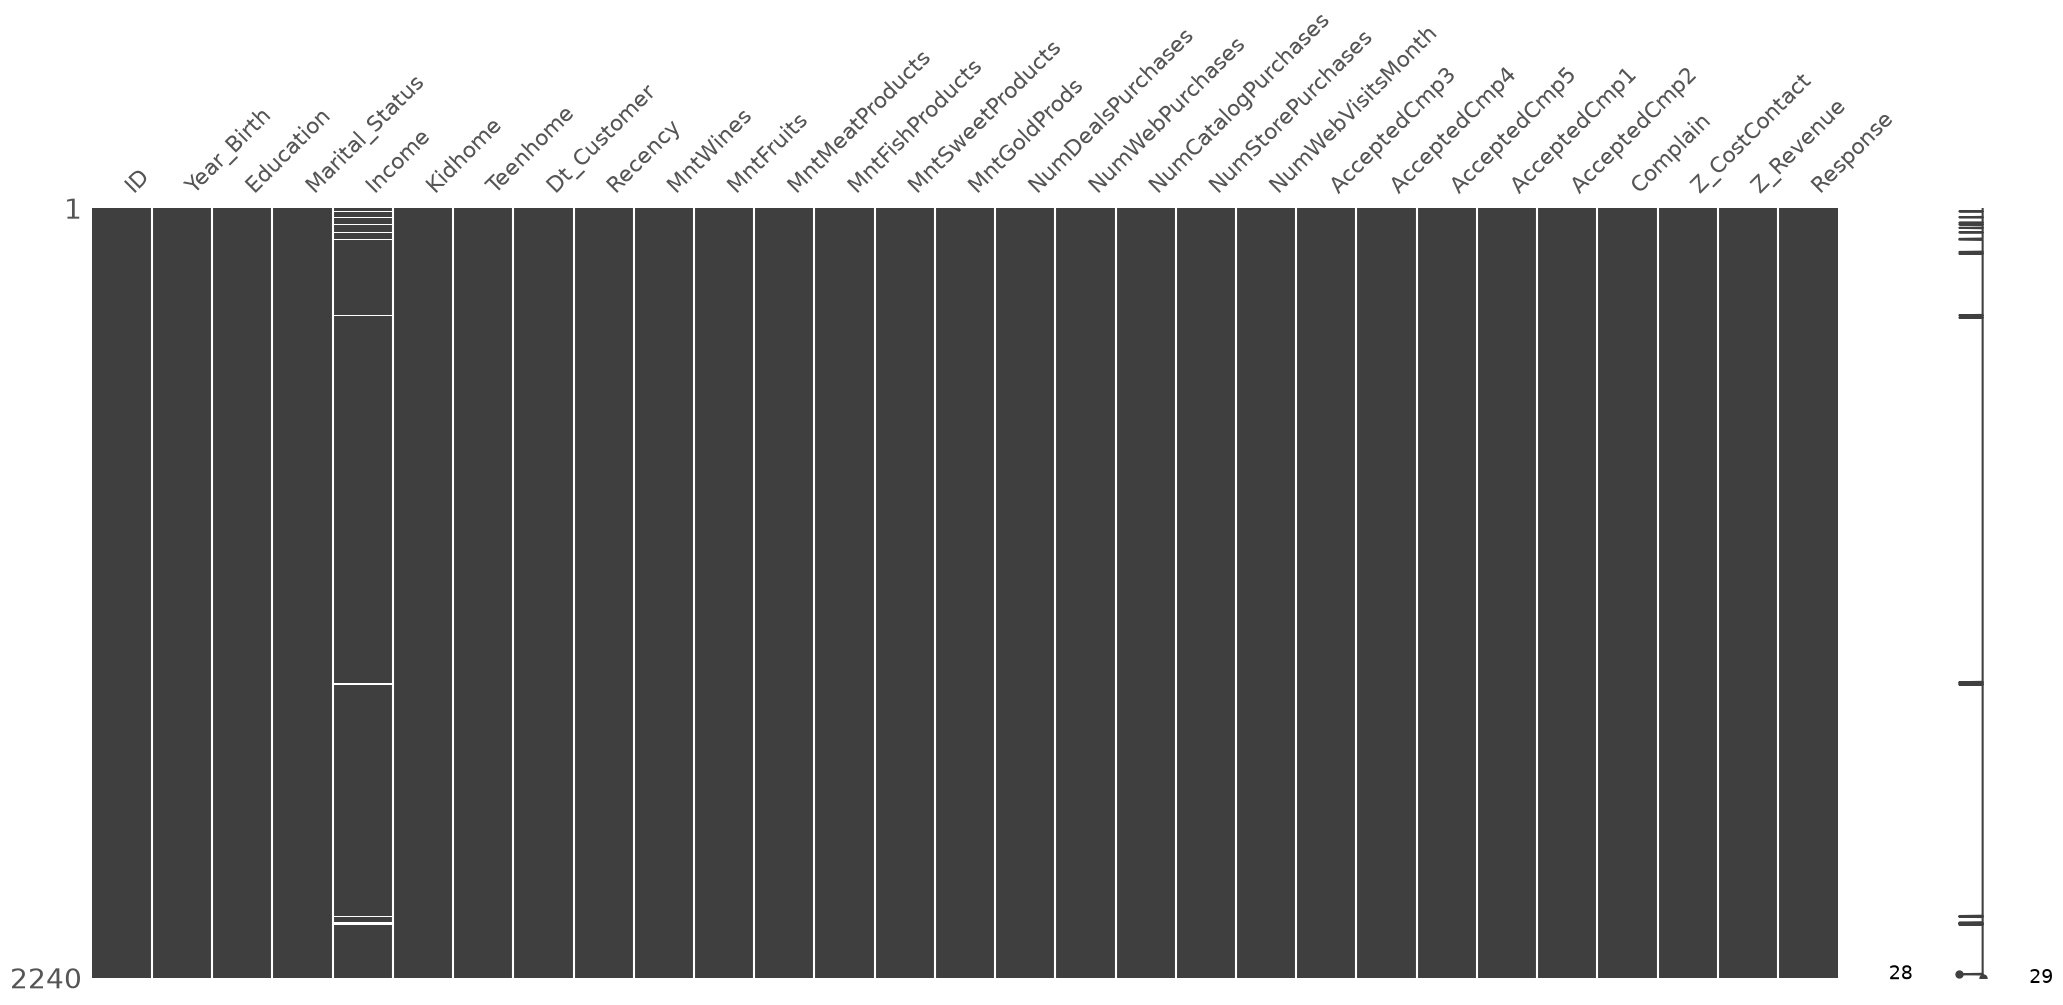

In [7]:
msno.matrix(df)

plt.savefig(
    "outputs/missing_values_matrix.png",
    bbox_inches="tight"
)

plt.show()

## Observation

The Income column contains missing values.

The percentage of missing values is very small compared to the total dataset size.

Median imputation is an appropriate strategy because Income contains extreme values and median is resistant to outliers.

# Feature Creation

The Year_Birth column is converted into Age to make analysis easier and more meaningful.

In [8]:
df["Age"] = 2025 - df["Year_Birth"]

df[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,68
1,1954,71
2,1965,60
3,1984,41
4,1981,44


# Outlier Detection Using IQR

Outliers are observations that are significantly different from the rest of the dataset.

The Interquartile Range (IQR) method is used for detecting outliers.

In [9]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Income"] < lower_bound) |
    (df["Income"] > upper_bound)
]

print("Outliers Found:", len(outliers))

Outliers Found: 8


## Income Boxplot

The boxplot provides a visual representation of outliers.

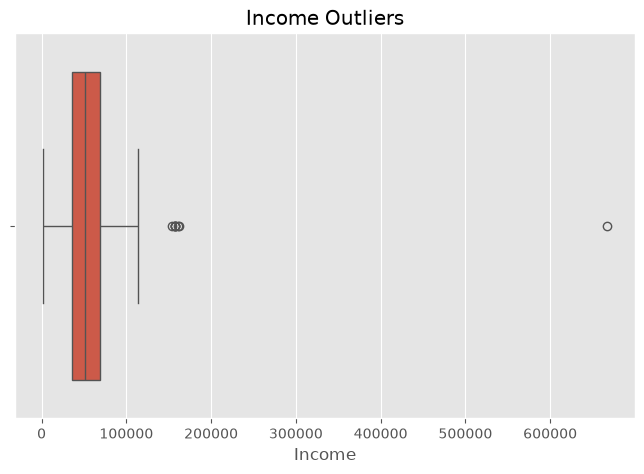

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Income"])

plt.title("Income Outliers")

plt.savefig(
    "outputs/income_boxplot.png"
)

plt.show()

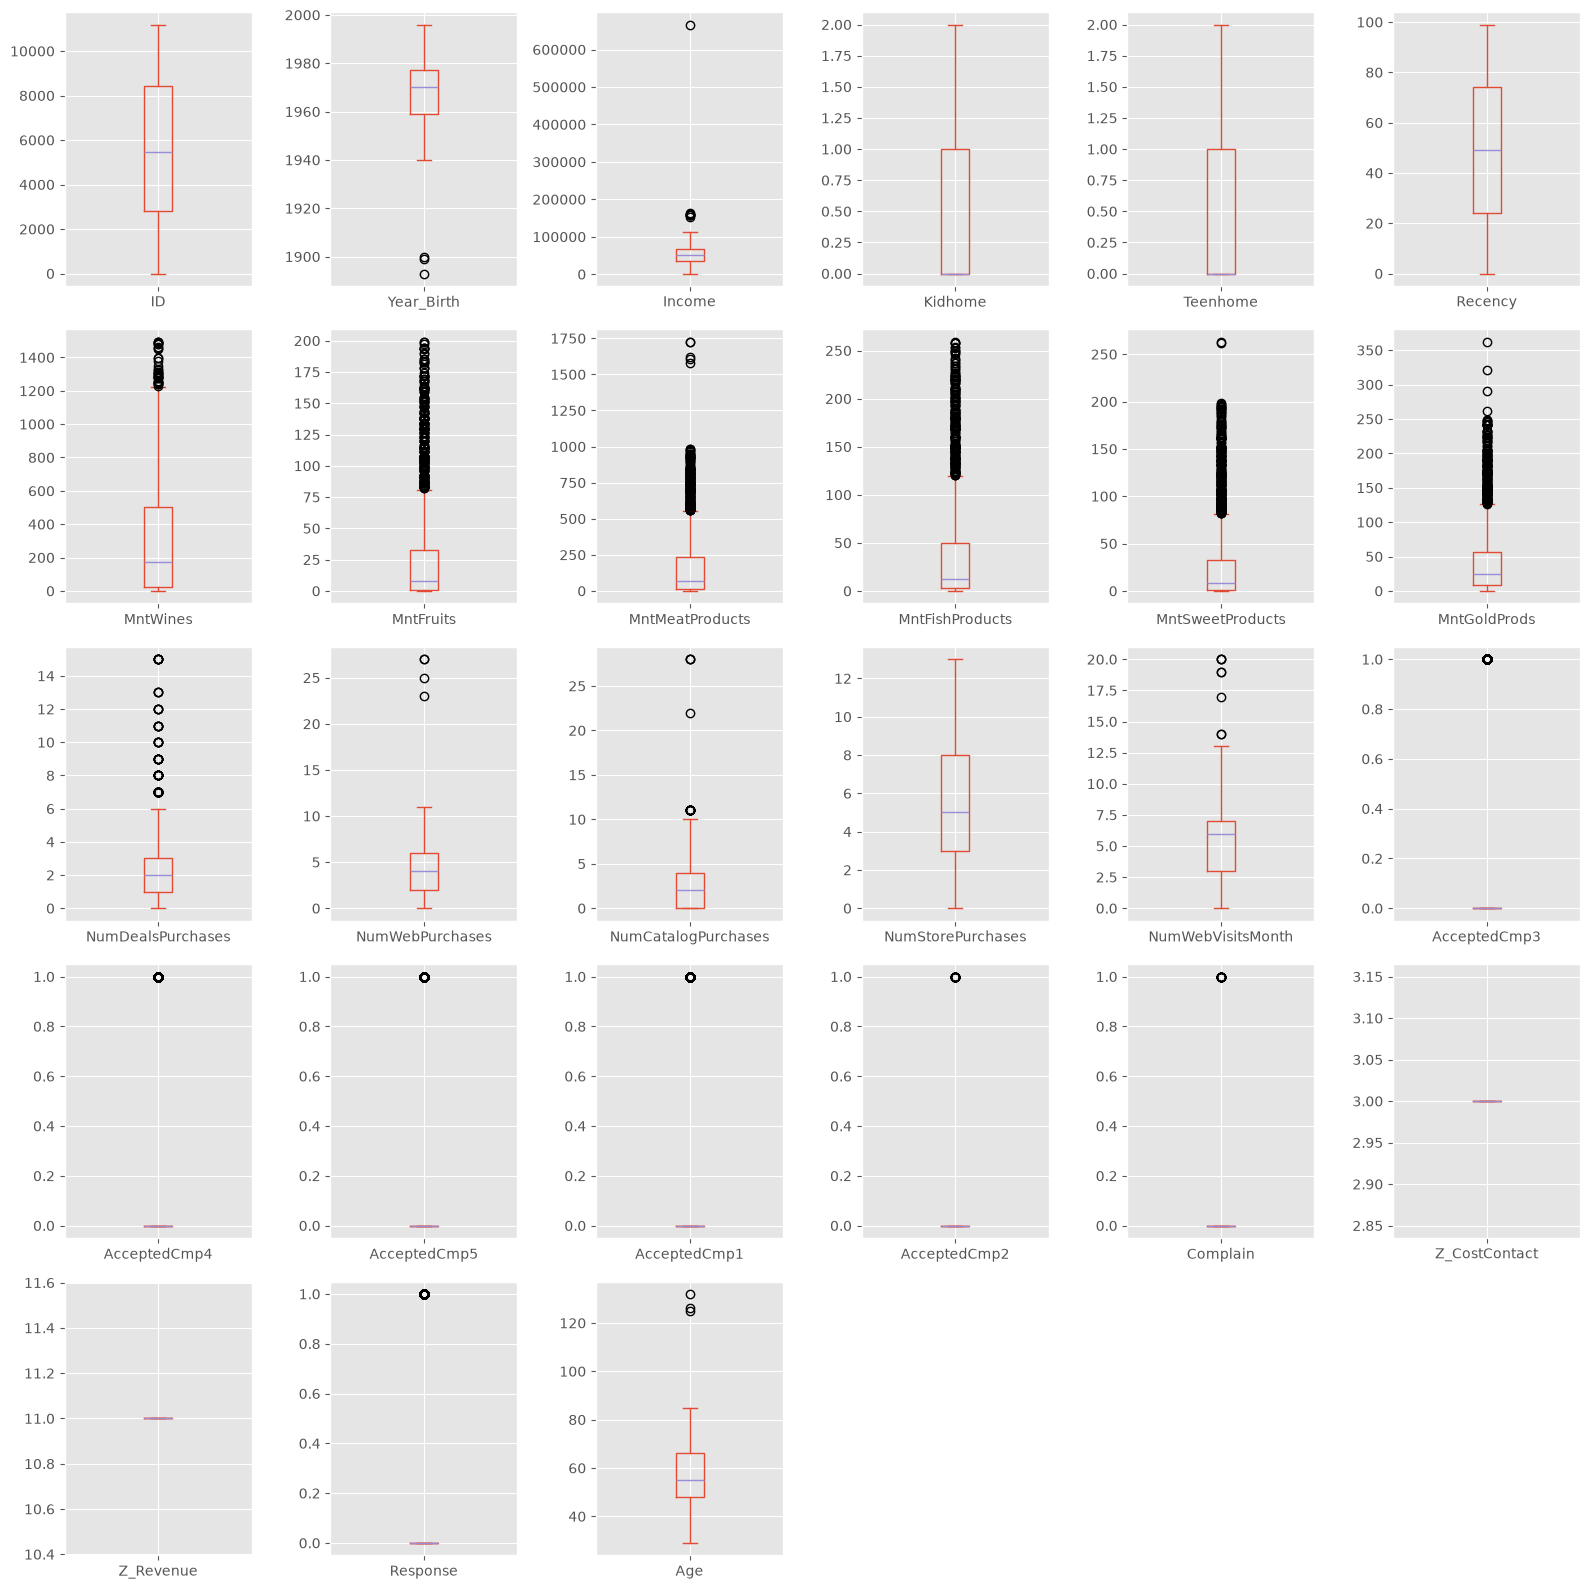

In [11]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns

df[numerical_cols].plot(
    kind="box",
    subplots=True,
    layout=(5,6),
    figsize=(16,16)
)

plt.tight_layout()

plt.savefig(
    "outputs/all_boxplots.png"
)

plt.show()

## Observation

Several spending-related columns contain outliers.

Examples:

- Income
- MntWines
- MntMeatProducts
- MntGoldProds

These observations may represent premium customers rather than data entry errors.

Therefore, outliers should not be removed without proper investigation.

# Distribution Analysis

Distribution analysis helps understand:

- Data spread
- Symmetry
- Skewness
- Normality

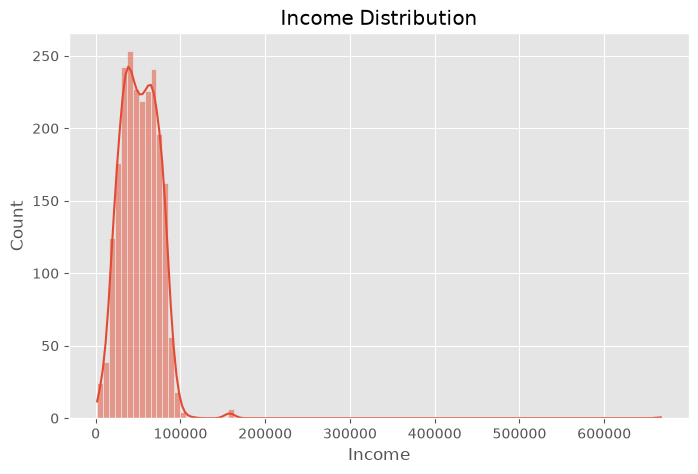

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Income"],
    kde=True
)

plt.title("Income Distribution")

plt.savefig(
    "outputs/income_distribution.png"
)

plt.show()

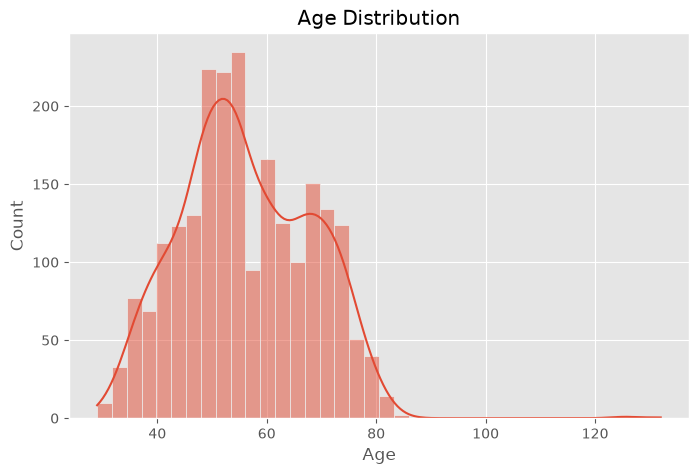

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    kde=True
)

plt.title("Age Distribution")

plt.savefig(
    "outputs/age_distribution.png"
)

plt.show()

# Skewness Analysis

Skewness measures how much a distribution deviates from symmetry.

Interpretation:

- 0 = Symmetric
- Positive = Right Skewed
- Negative = Left Skewed

In [14]:
df[["Income"]].skew()

Income    6.763487
dtype: float64

# Log Transformation

Income is transformed using Log Transformation to reduce skewness.

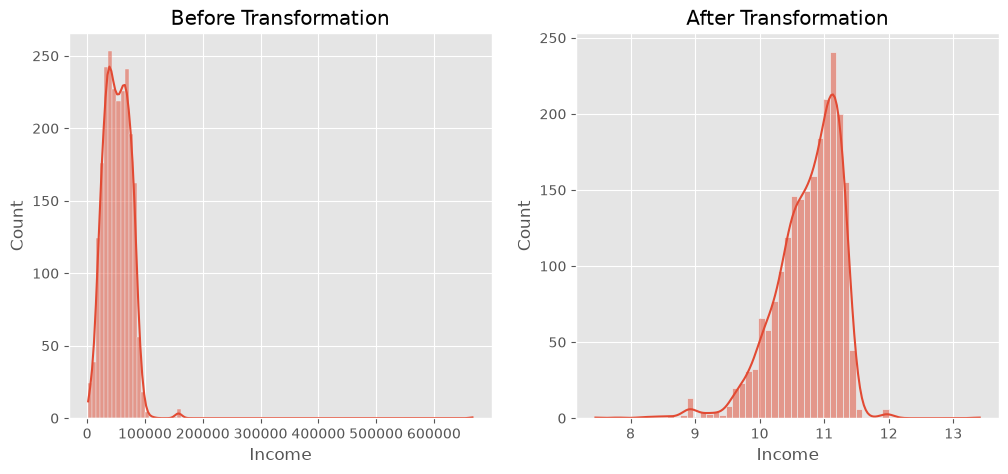

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    df["Income"],
    kde=True
)

plt.title("Before Transformation")

plt.subplot(1,2,2)

sns.histplot(
    np.log1p(df["Income"]),
    kde=True
)

plt.title("After Transformation")

plt.savefig(
    "outputs/income_log_transform.png"
)

plt.show()

## Observation

The Income feature is positively skewed.

After applying logarithmic transformation, the distribution becomes more balanced and closer to a normal distribution.

# Target Variable Analysis

The Response feature is used as the target variable.

Response = 1 → Customer accepted the campaign.

Response = 0 → Customer did not accept the campaign.

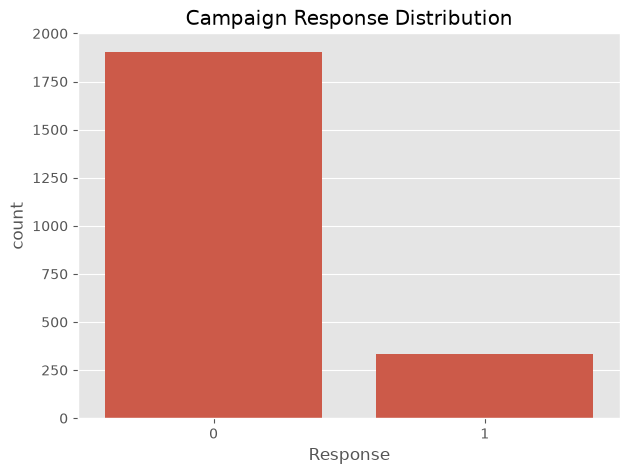

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Response",
    data=df
)

plt.title(
    "Campaign Response Distribution"
)

plt.savefig(
    "outputs/response_distribution.png"
)

plt.show()

## Observation

Most customers belong to Response = 0.

This indicates class imbalance.

Class imbalance should be considered during Machine Learning model development because it may affect prediction performance.

# Final Conclusion

The Advanced EDA revealed several important insights about the Customer Personality Analysis dataset.

Key Findings:

- Income contains missing values.
- Spending-related features contain outliers.
- Income distribution is positively skewed.
- Log transformation improves distribution symmetry.
- The target variable is imbalanced.
- Premium customers contribute to extreme spending values.

These findings will help during Feature Engineering and Machine Learning model development in upcoming tasks.